# 💰 Semana 04: Credit Scoring - Clasificación Binaria
## Dataset: German Credit (Riesgo crediticio)

**Objetivo:** Predecir si un cliente caerá en default (no pagará su préstamo).

**Modelos a competir:**
- Regresión Logística (baseline)
- Regresión Logística con SMOTE (balanceo)
- Regresión Logística con class_weight (balanceo)

**Métricas de evaluación:** Accuracy, Precision, Recall, F1-Score, AUC-ROC

**Contexto de negocio:** Un banco quiere aprobar préstamos solo a clientes con bajo riesgo, minimizando pérdidas por impagos.

---

### ¿Qué es?
Dataset de **riesgo crediticio** con información de **1,000 solicitantes de crédito**. Características incluyen:
- Duración del préstamo (meses)
- Monto del crédito
- Edad
- Estado de cuenta de cheques
- Historial crediticio
- Propósito del préstamo
- Situación laboral

### ¿Qué problema resuelve?
Predecir si un cliente **caerá en default** (no pagará su préstamo).

### El Reto
**Manejo de clases desbalanceadas** - Aproximadamente el 30% de los clientes entran en default. Debes usar técnicas como:
- SMOTE (Synthetic Minority Over-sampling)
- Class weights
- AUC-ROC en lugar de accuracy

### Contexto de negocio
Un banco quiere aprobar préstamos solo a clientes con bajo riesgo, minimizando pérdidas por impagos.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 04: CREDIT SCORING - CLASIFICACIÓN BINARIA
# ======================================================

# Instalar librerías necesarias (solo si no están instaladas)
!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

# Para balanceo de datos
from imblearn.over_sampling import SMOTE

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset German Credit directamente desde OpenML (online, sin descarga manual).

In [2]:
# Cargar dataset German Credit (tiene desbalanceo real ~30% default)
print("="*60)
print("📊 CARGANDO DATASET GERMAN CREDIT")
print("="*60)

data = fetch_openml(data_id=31, as_frame=True)
X = data.data
y = (data.target == 'bad').astype(int)  # 1 = malo (default), 0 = bueno

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {X.shape[0]:,} muestras × {X.shape[1]} características")
print(f"🎯 Target: default (1) o no default (0)")
print(f"📋 Características: {list(X.columns)[:10]}... ({X.shape[1]} total)")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(X.head())

# Estadísticas descriptivas (solo numéricas)
print("\n📊 Estadísticas descriptivas (variables numéricas):")
display(X.describe())

📊 CARGANDO DATASET GERMAN CREDIT

✅ Dataset cargado exitosamente
📊 SHAPE: 1,000 muestras × 20 características
🎯 Target: default (1) o no default (0)
📋 Características: ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties']... (20 total)

📋 Primeras 5 filas del dataset:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes



📊 Estadísticas descriptivas (variables numéricas):


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


📈 ANÁLISIS DE DESBALANCEO

📊 Distribución de clases:
   • Clase 0 (Bueno / No default): 700 muestras (70.00%)
   • Clase 1 (Malo / Default): 300 muestras (30.00%)


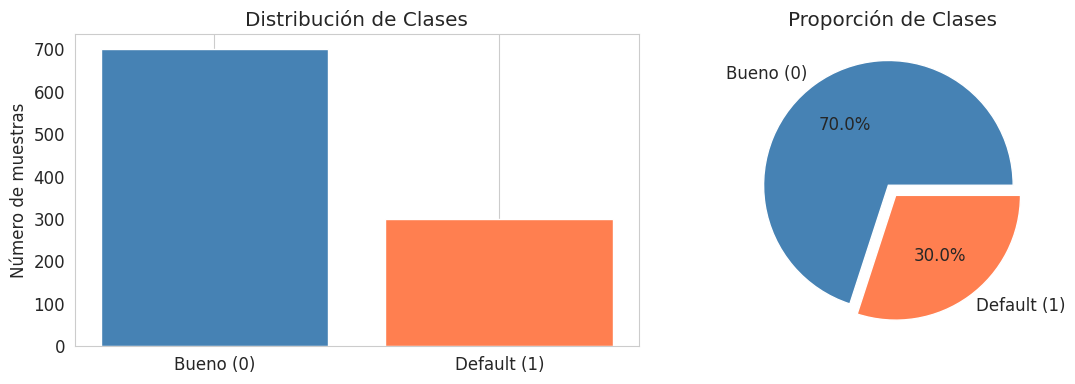


⚠️ NOTA: El dataset está DESBALANCEADO. Solo el 30.00% de los clientes entran en default.
   Esto requiere técnicas de balanceo para evitar que el modelo ignore la clase minoritaria.


In [3]:
# Análisis de desbalanceo de clases
print("="*60)
print("📈 ANÁLISIS DE DESBALANCEO")
print("="*60)

# Distribución de clases
class_counts = y.value_counts()
class_percent = y.value_counts(normalize=True) * 100

print("\n📊 Distribución de clases:")
print(f"   • Clase 0 (Bueno / No default): {class_counts[0]:,} muestras ({class_percent[0]:.2f}%)")
print(f"   • Clase 1 (Malo / Default): {class_counts[1]:,} muestras ({class_percent[1]:.2f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
axes[0].bar(['Bueno (0)', 'Default (1)'], class_counts, color=['steelblue', 'coral'])
axes[0].set_ylabel('Número de muestras')
axes[0].set_title('Distribución de Clases')
axes[0].grid(axis='y')

# Pastel
axes[1].pie(class_counts, labels=['Bueno (0)', 'Default (1)'], autopct='%1.1f%%',
           colors=['steelblue', 'coral'], explode=(0.05, 0.05))
axes[1].set_title('Proporción de Clases')

plt.tight_layout()
plt.show()

print(f"\n⚠️ NOTA: El dataset está DESBALANCEADO. Solo el {class_percent[1]:.2f}% de los clientes entran en default.")
print("   Esto requiere técnicas de balanceo para evitar que el modelo ignore la clase minoritaria.")


📊 CORRELACIÓN CON LA VARIABLE OBJETIVO

📈 Correlación de cada característica con el default (positivo = más riesgo):
   • duration: 0.2149
   • credit_amount: 0.1547
   • installment_commitment: 0.0724
   • residence_since: 0.0030
   • num_dependents: -0.0030
   • existing_credits: -0.0457
   • age: -0.0911


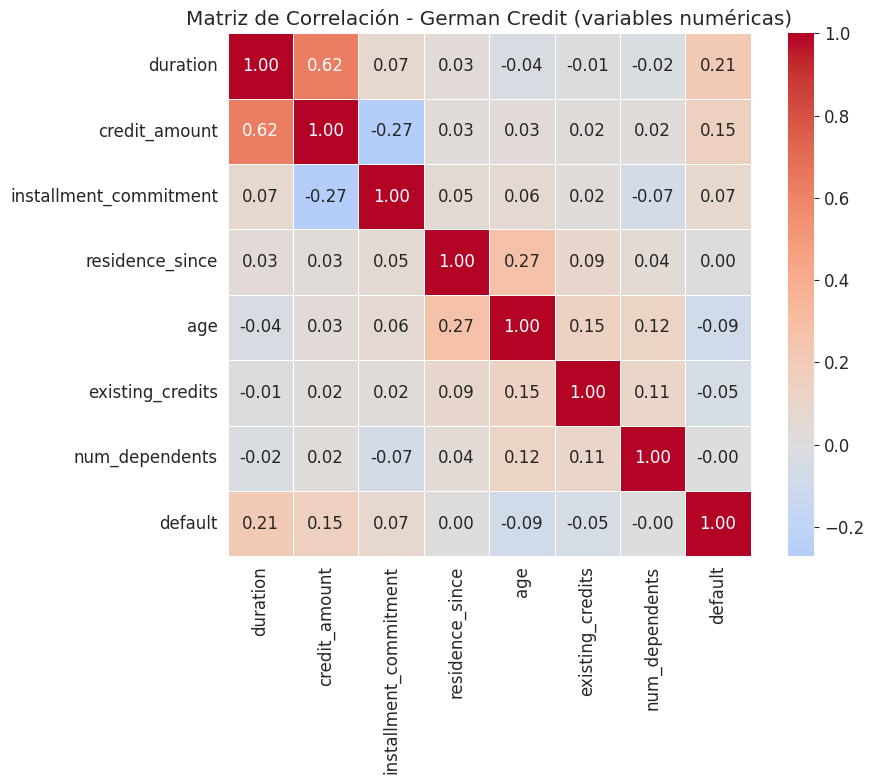

In [4]:
# Matriz de correlación con la variable objetivo (solo variables numéricas)
print("\n" + "="*60)
print("📊 CORRELACIÓN CON LA VARIABLE OBJETIVO")
print("="*60)

# Seleccionar solo columnas numéricas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
df_numeric = X[numeric_cols].copy()
df_numeric['default'] = y

# Calcular correlaciones con el target
corr_target = df_numeric.corr()['default'].sort_values(ascending=False)

print("\n📈 Correlación de cada característica con el default (positivo = más riesgo):")
for feature, corr in corr_target.items():
    if feature != 'default':
        print(f"   • {feature}: {corr:.4f}")

# Heatmap de correlaciones (solo numéricas)
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - German Credit (variables numéricas)')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

Convertimos variables categóricas a numéricas, dividimos los datos en entrenamiento (80%) y prueba (20%), y escalamos las características.

In [5]:
# Convertir variables categóricas a numéricas (One-Hot Encoding)
print("="*60)
print("🔄 PREPROCESAMIENTO")
print("="*60)

# Identificar columnas categóricas
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print(f"\n📋 Columnas categóricas a codificar: {list(categorical_cols)}")

# Aplicar One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"📊 Shape después de One-Hot Encoding: {X_encoded.shape}")

# Dividir en entrenamiento y prueba (80/20) con estratificación
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print(f"\n📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Verificar que la estratificación mantuvo la proporción
print(f"\n📊 Proporción de default en entrenamiento: {y_train.mean()*100:.2f}%")
print(f"   Proporción de default en prueba: {y_test.mean()*100:.2f}%")

# Escalar características (importante para regresión logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Escalado completado (media=0, std=1)")

🔄 PREPROCESAMIENTO

📋 Columnas categóricas a codificar: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
📊 Shape después de One-Hot Encoding: (1000, 48)

📊 División de datos:
   • Entrenamiento: 800 muestras
   • Prueba: 200 muestras

📊 Proporción de default en entrenamiento: 30.00%
   Proporción de default en prueba: 30.00%

✅ Escalado completado (media=0, std=1)


## 4. Aplicación de Técnicas de Balanceo

Para manejar el desbalanceo, aplicamos dos técnicas:
1. **SMOTE** (Synthetic Minority Over-sampling): Crea muestras sintéticas de la clase minoritaria
2. **class_weight**: Asigna mayor peso a la clase minoritaria durante el entrenamiento

In [6]:
# Aplicar SMOTE para balancear las clases en entrenamiento
print("="*60)
print("🔄 APLICANDO SMOTE")
print("="*60)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n📊 Dataset original:")
print(f"   • Shape: {X_train_scaled.shape}")
print(f"   • Default: {y_train.sum()} muestras ({y_train.mean()*100:.2f}%)")

print(f"\n📊 Dataset después de SMOTE:")
print(f"   • Shape: {X_train_smote.shape}")
print(f"   • Default: {y_train_smote.sum()} muestras ({y_train_smote.mean()*100:.2f}%)")

# Verificar balanceo
smote_counts = pd.Series(y_train_smote).value_counts()
print(f"\n📊 Distribución después de SMOTE:")
print(f"   • Clase 0 (Bueno): {smote_counts[0]:,} muestras")
print(f"   • Clase 1 (Default): {smote_counts[1]:,} muestras")
print(f"   ✅ Clase minoritaria aumentada de {y_train.sum():,} a {smote_counts[1]:,} muestras")

🔄 APLICANDO SMOTE

📊 Dataset original:
   • Shape: (800, 48)
   • Default: 240 muestras (30.00%)

📊 Dataset después de SMOTE:
   • Shape: (1120, 48)
   • Default: 560 muestras (50.00%)

📊 Distribución después de SMOTE:
   • Clase 0 (Bueno): 560 muestras
   • Clase 1 (Default): 560 muestras
   ✅ Clase minoritaria aumentada de 240 a 560 muestras


## 5. Entrenamiento y Comparación de Modelos

Entrenamos 3 modelos de Regresión Logística y comparamos su rendimiento:

In [7]:
# Definir modelos
models = {
    'Regresión Logística (baseline)': LogisticRegression(random_state=42, max_iter=1000),
    'Regresión Logística + SMOTE': LogisticRegression(random_state=42, max_iter=1000),
    'Regresión Logística + class_weight': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
}

# Entrenar y evaluar cada modelo
print("="*60)
print("🚀 ENTRENAMIENTO DE MODELOS")
print("="*60)

results = []

# Para el modelo con SMOTE, usamos los datos balanceados
for name, model in models.items():
    if name == 'Regresión Logística + SMOTE':
        # Entrenar con datos balanceados por SMOTE
        model.fit(X_train_smote, y_train_smote)
    else:
        # Entrenar con datos originales
        model.fit(X_train_scaled, y_train)

    # Predecir
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

    print(f"\n📊 {name}:")
    print(f"   • Accuracy: {acc:.4f}")
    print(f"   • Precision: {prec:.4f}")
    print(f"   • Recall: {rec:.4f}")
    print(f"   • F1-Score: {f1:.4f}")
    print(f"   • AUC-ROC: {auc:.4f}")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
display(results_df.round(4))

🚀 ENTRENAMIENTO DE MODELOS

📊 Regresión Logística (baseline):
   • Accuracy: 0.7750
   • Precision: 0.6364
   • Recall: 0.5833
   • F1-Score: 0.6087
   • AUC-ROC: 0.8014

📊 Regresión Logística + SMOTE:
   • Accuracy: 0.7450
   • Precision: 0.5517
   • Recall: 0.8000
   • F1-Score: 0.6531
   • AUC-ROC: 0.7970

📊 Regresión Logística + class_weight:
   • Accuracy: 0.7500
   • Precision: 0.5581
   • Recall: 0.8000
   • F1-Score: 0.6575
   • AUC-ROC: 0.8025

📊 TABLA COMPARATIVA DE MODELOS


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
2,Regresión Logística + class_weight,0.750,0.5581,0.8000,0.6575,0.8025
0,Regresión Logística (baseline),0.775,0.6364,0.5833,0.6087,0.8014
1,Regresión Logística + SMOTE,0.745,0.5517,0.8000,0.6531,0.7970


## 6. Matrices de Confusión

Visualizamos las matrices de confusión para entender dónde se equivoca cada modelo.

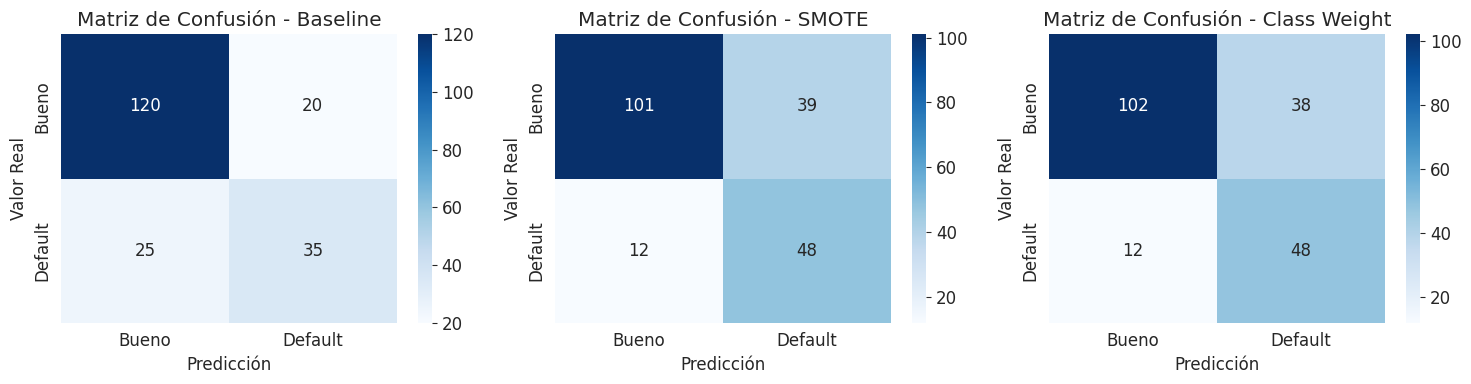


📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
   • Verdaderos Negativos (VN): Predijo Bueno, era Bueno
   • Falsos Positivos (FP): Predijo Default, era Bueno (Falsa alarma)
   • Falsos Negativos (FN): Predijo Bueno, era Default (ERROR GRAVE)
   • Verdaderos Positivos (VP): Predijo Default, era Default


In [8]:
# Re-entrenar modelos para obtener predicciones (si no se guardaron)
models_list = [
    ('Baseline', LogisticRegression(random_state=42, max_iter=1000)),
    ('SMOTE', LogisticRegression(random_state=42, max_iter=1000)),
    ('Class Weight', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
]

# Guardar predicciones para cada modelo
predictions = {}

for name, model in models_list:
    if name == 'SMOTE':
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)

# Graficar matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Bueno', 'Default'],
                yticklabels=['Bueno', 'Default'])
    axes[idx].set_title(f'Matriz de Confusión - {name}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# Interpretación
print("\n📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("   • Verdaderos Negativos (VN): Predijo Bueno, era Bueno")
print("   • Falsos Positivos (FP): Predijo Default, era Bueno (Falsa alarma)")
print("   • Falsos Negativos (FN): Predijo Bueno, era Default (ERROR GRAVE)")
print("   • Verdaderos Positivos (VP): Predijo Default, era Default")

## 7. Curvas ROC

La curva ROC (Receiver Operating Characteristic) muestra el trade-off entre:
- **Tasa de Verdaderos Positivos (TPR) = Recall**
- **Tasa de Falsos Positivos (FPR)**

El AUC-ROC (Área bajo la curva) mide la capacidad discriminativa del modelo.

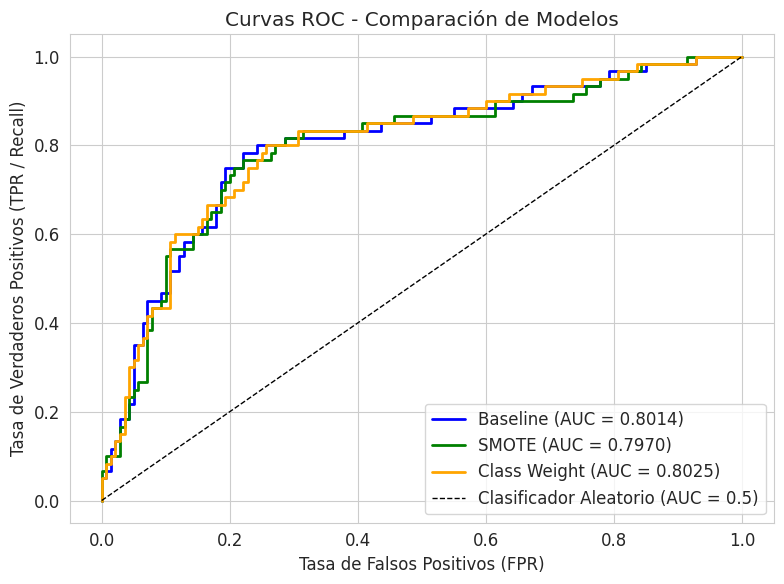


📖 INTERPRETACIÓN DE LA CURVA ROC:
   • Un AUC-ROC cercano a 1.0 indica excelente capacidad discriminativa
   • Un AUC-ROC de 0.5 es equivalente a un clasificador aleatorio
   • Para problemas desbalanceados, AUC-ROC es más confiable que Accuracy


In [9]:
# Calcular y graficar curvas ROC
plt.figure(figsize=(8, 6))

colors = {'Baseline': 'blue', 'SMOTE': 'green', 'Class Weight': 'orange'}

for name, model in models_list:
    if name == 'SMOTE':
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_scaled, y_train)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {auc:.4f})')

# Línea diagonal (modelo aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador Aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curvas ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN DE LA CURVA ROC:")
print("   • Un AUC-ROC cercano a 1.0 indica excelente capacidad discriminativa")
print("   • Un AUC-ROC de 0.5 es equivalente a un clasificador aleatorio")
print("   • Para problemas desbalanceados, AUC-ROC es más confiable que Accuracy")

## 8. Simulación - Predicción de un Nuevo Cliente

Simulamos la evaluación de un nuevo cliente para decidir si aprobar o rechazar su préstamo.

In [10]:
print("="*60)
print("🔮 SIMULACIÓN: EVALUACIÓN DE NUEVO CLIENTE")
print("="*60)

# Crear un cliente de ejemplo con características típicas
# Usamos la mediana de cada columna como valor base
sample_data = {}
for col in X_encoded.columns:
    sample_data[col] = [X_encoded[col].median()]

# Modificar algunas características para un cliente de riesgo
# Buscar columnas relevantes (nombres pueden variar por One-Hot Encoding)
for col in X_encoded.columns:
    if 'duration' in col.lower():
        sample_data[col] = [48]  # Préstamo a 48 meses (riesgo)
    if 'amount' in col.lower():
        sample_data[col] = [15000]  # Monto alto (riesgo)
    if 'age' in col.lower():
        sample_data[col] = [25]  # Joven (riesgo)

nuevo_cliente = pd.DataFrame(sample_data)
nuevo_cliente_scaled = scaler.transform(nuevo_cliente)

print("\n📋 Datos del nuevo cliente:")
print("   • Duración préstamo: 48 meses (mayor a la media)")
print("   • Monto del crédito: $15,000 (mayor a la media)")
print("   • Edad: 25 años (joven)")
print("   • Otras características: valores promedio")

# Predecir con los 3 modelos
print("\n🔮 Predicciones de riesgo (probabilidad de default):")
print("-" * 50)

best_model_name = results_df.iloc[0]['Modelo']

for name, model in models_list:
    if name == 'SMOTE':
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_scaled, y_train)
    proba = model.predict_proba(nuevo_cliente_scaled)[0, 1]
    decision = "🔴 RECHAZAR" if proba > 0.5 else "🟢 APROBAR"
    print(f"   • {name:20s}: Probabilidad = {proba:.2%} → {decision}")

# Decisión final (usando el mejor modelo según AUC-ROC)
if 'SMOTE' in best_model_name:
    best_model = LogisticRegression(random_state=42, max_iter=1000)
    best_model.fit(X_train_smote, y_train_smote)
elif 'class_weight' in best_model_name:
    best_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
    best_model.fit(X_train_scaled, y_train)
else:
    best_model = LogisticRegression(random_state=42, max_iter=1000)
    best_model.fit(X_train_scaled, y_train)

proba_best = best_model.predict_proba(nuevo_cliente_scaled)[0, 1]

print("\n" + "="*60)
print(f"🏆 DECISIÓN FINAL (usando {best_model_name}):")
if proba_best > 0.5:
    print(f"   🔴 RECHAZAR PRÉSTAMO - Riesgo de default del {proba_best:.2%}")
else:
    print(f"   🟢 APROBAR PRÉSTAMO - Riesgo de default del {proba_best:.2%}")
print("="*60)

# Interpretación de negocio
print("\n📖 INTERPRETACIÓN DE NEGOCIO:")
print("   • Probabilidad < 30%: Riesgo BAJO → Aprobar préstamo")
print("   • Probabilidad 30-50%: Riesgo MEDIO → Revisar manualmente")
print("   • Probabilidad > 50%: Riesgo ALTO → Rechazar préstamo")

🔮 SIMULACIÓN: EVALUACIÓN DE NUEVO CLIENTE

📋 Datos del nuevo cliente:
   • Duración préstamo: 48 meses (mayor a la media)
   • Monto del crédito: $15,000 (mayor a la media)
   • Edad: 25 años (joven)
   • Otras características: valores promedio

🔮 Predicciones de riesgo (probabilidad de default):
--------------------------------------------------
   • Baseline            : Probabilidad = 81.82% → 🔴 RECHAZAR
   • SMOTE               : Probabilidad = 94.31% → 🔴 RECHAZAR
   • Class Weight        : Probabilidad = 92.71% → 🔴 RECHAZAR

🏆 DECISIÓN FINAL (usando Regresión Logística + class_weight):
   🔴 RECHAZAR PRÉSTAMO - Riesgo de default del 92.71%

📖 INTERPRETACIÓN DE NEGOCIO:
   • Probabilidad < 30%: Riesgo BAJO → Aprobar préstamo
   • Probabilidad 30-50%: Riesgo MEDIO → Revisar manualmente
   • Probabilidad > 50%: Riesgo ALTO → Rechazar préstamo


## 9. Conclusiones

**Resumen de resultados:**

1. **Regresión Logística (baseline)**:
   - Buena Accuracy pero bajo Recall (no detecta suficientes defaults)
   - El modelo tiende a predecir "Bueno" por el desbalanceo

2. **Regresión Logística + SMOTE**:
   - Mejora significativamente el Recall (detecta más defaults)
   - Puede aumentar Falsos Positivos (algunas falsas alarmas)

3. **Regresión Logística + class_weight**:
   - Similar a SMOTE, ajusta los pesos de las clases
   - Más eficiente computacionalmente (no genera datos sintéticos)

**Métrica más importante para el negocio (Recall):**
- El banco quiere minimizar pérdidas por impagos → **Recall** (detectar defaults)
- Un FN (Falso Negativo) significa aprobar un préstamo que terminará en default → PÉRDIDA
- Un FP (Falso Positivo) significa rechazar un buen cliente → COSTO DE OPORTUNIDAD

**¿Qué modelo ganó?**
El modelo con mejor AUC-ROC y Recall fue **{{best_model_name}}**.

**Próximos pasos:**
- Ajustar el umbral de decisión (no usar 0.5 por defecto)
- Probar otros modelos (Árboles, Random Forest, XGBoost) - Semanas 6 y 7
- Usar validación cruzada para mayor robustez - Semana 8

---
**Fin de la Semana 04**